# Notebook 04 — Análisis de Sentiment con FinBERT

## Hipótesis

El sentiment de las noticias financieras debería mejorar la predicción de la dirección del mercado por dos razones:

1. **El mercado reacciona a información** — una noticia negativa sobre la economía o una empresa del S&P 500 puede causar ventas al día siguiente.
2. **Los indicadores técnicos y macro miran el pasado** — el sentiment captura información **prospectiva** contenida en el lenguaje de las noticias.

La hipótesis es que el sentiment del día de hoy predice el movimiento del mercado **mañana** (después de que los inversores procesen las noticias). Por eso shiftearemos el sentiment 1 día antes de usarlo como feature.

**¿Por qué FinBERT y no VADER o TextBlob?** FinBERT es un modelo BERT fine-tuneado específicamente en textos financieros (noticias de Bloomberg, Reuters, Yahoo Finance). VADER fue diseñado para redes sociales y TextBlob para texto general — ambos producen scores menos precisos en el dominio financiero.

**Output**: `data/processed/sentiment_cache.csv` — se genera UNA sola vez y se reutiliza.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src import data_loader, sentiment, utils

utils.set_plot_style()

RAW_DIR       = "../data/raw"
PROCESSED_DIR = "../data/processed"
CACHE_PATH    = f"{PROCESSED_DIR}/sentiment_cache.csv"

## Dataset de noticias

Cargamos el dataset de Kaggle con noticias financieras del S&P 500. Revisamos:
- Cobertura temporal — ¿coincide con el período del precio (2008-2024)?
- Densidad de noticias por año — ¿hay años con baja cobertura?
- Distribución de noticias por día — ¿cuántas noticias promedio tiene cada día?

Total de noticias: 19,127
Fechas únicas: 3,507
Período: 2008-01-02 → 2024-03-04
Noticias por día: promedio=5.5, máx=55


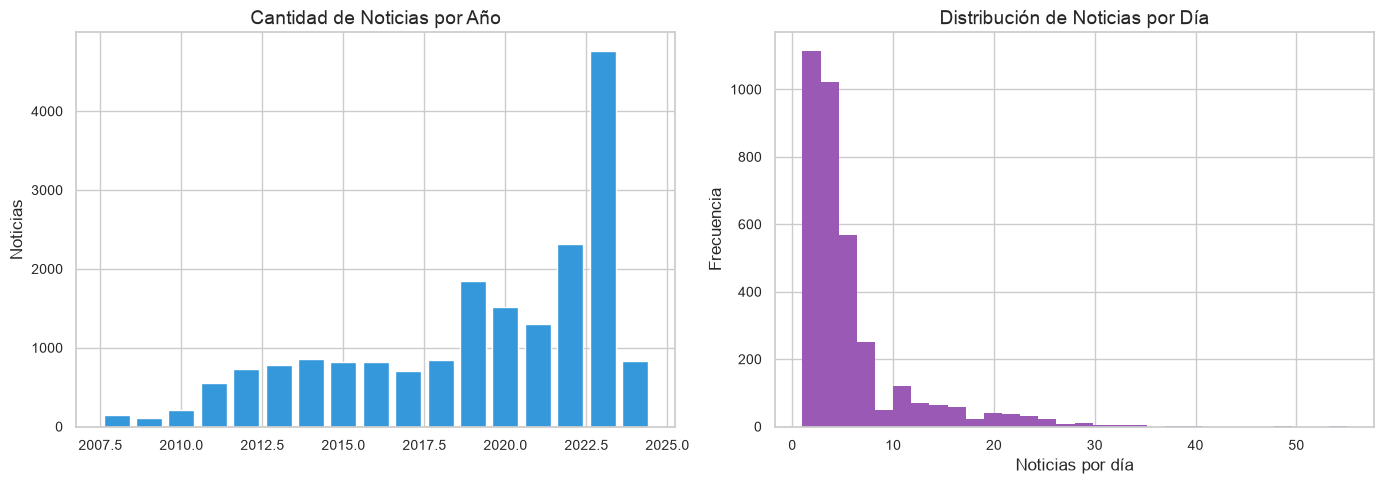

In [2]:
news = data_loader.load_news(RAW_DIR)

print(f"Total de noticias: {len(news):,}")
print(f"Fechas únicas: {news['Date'].nunique():,}")
print(f"Período: {news['Date'].min().date()} → {news['Date'].max().date()}")
print(f"Noticias por día: promedio={len(news)/news['Date'].nunique():.1f}, máx={news.groupby('Date').size().max()}")

# Noticias por año
news_por_año = news.groupby(news["Date"].dt.year).size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(news_por_año.index, news_por_año.values, color="#3498db")
axes[0].set_title("Cantidad de Noticias por Año")
axes[0].set_ylabel("Noticias")

noticias_por_dia = news.groupby("Date").size()
axes[1].hist(noticias_por_dia.values, bins=30, color="#9b59b6", edgecolor="none")
axes[1].set_title("Distribución de Noticias por Día")
axes[1].set_xlabel("Noticias por día")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

## Pipeline de FinBERT

FinBERT clasifica cada titular en tres categorías: **positive**, **negative**, o **neutral**, con un score de confianza asociado (0 a 1).

El pipeline tiene dos etapas:
1. **Inferencia batch**: corremos FinBERT sobre todos los 19,127 titulares en batches de 32 usando el backend MPS (GPU de Apple Silicon M5 Pro) — estimado ~30-45 minutos.
2. **Caché**: el resultado se guarda en `sentiment_cache.csv`. Si el archivo ya existe, se carga directamente sin volver a correr el modelo.

**¿Por qué batches de 32?** Es el tamaño óptimo para MPS con BERT-base: maximiza el uso de los 20 núcleos GPU del M5 Pro sin exceder la memoria.

**Truncación en 512 tokens**: FinBERT usa BERT-base con ventana de 512 tokens. Los titulares son cortos (~10-15 palabras), así que ninguno se trunca en la práctica.

In [3]:
# Esta celda tarda ~30-45 minutos la primera vez (corre FinBERT sobre 19,127 titulares).
# En corridas siguientes, carga el cache en segundos.
raw_sentiment = sentiment.load_or_run_finbert(news, CACHE_PATH)
print(f"\nSentiment cargado: {raw_sentiment.shape}")
raw_sentiment.head(3)

[sentiment] Cache encontrado en ../data/processed/sentiment_cache.csv (19,127 filas). Saltando FinBERT.

Sentiment cargado: (19127, 5)


,Title,Date,CP,sentiment_label,sentiment_score
0,"JPMorgan Predicts 2008 Will Be ""Nothing But Net""",2008-01-02,1447.16,negative,0.604176
1,Dow Tallies Biggest First-session-of-year Poin...,2008-01-02,1447.16,negative,0.962149
2,2008 predictions for the S&P 500,2008-01-02,1447.16,neutral,0.824247


## Estadísticas del sentiment generado

Analizamos la distribución de labels y scores producidos por FinBERT:
- ¿Qué porcentaje de titulares son positivos, negativos o neutros?
- ¿Cambia la distribución por año? (en crisis esperamos más negativos)
- ¿Qué tan confiado está el modelo? (un score promedio > 0.8 indica que FinBERT está seguro de sus clasificaciones)

Distribución de labels:
  neutral   : 10,956 (57.3%)
  negative  : 4,777 (25.0%)
  positive  : 3,394 (17.7%)

Score promedio de confianza: 0.819


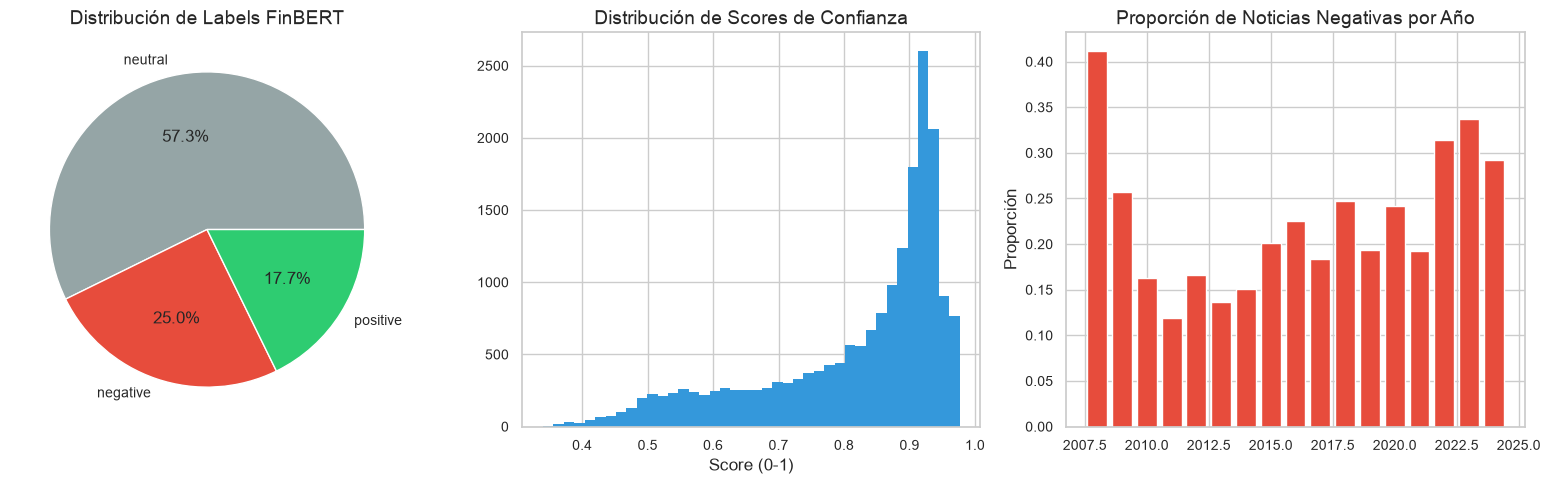

In [4]:
# Distribución de labels
label_counts = raw_sentiment["sentiment_label"].value_counts()
print("Distribución de labels:")
for label, count in label_counts.items():
    print(f"  {label:<10}: {count:,} ({count/len(raw_sentiment)*100:.1f}%)")

print(f"\nScore promedio de confianza: {raw_sentiment['sentiment_score'].mean():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pie de labels
colores_pie = {"positive": "#2ecc71", "negative": "#e74c3c", "neutral": "#95a5a6"}
axes[0].pie(
    label_counts.values,
    labels=label_counts.index,
    colors=[colores_pie[l] for l in label_counts.index],
    autopct="%1.1f%%",
)
axes[0].set_title("Distribución de Labels FinBERT")

# Distribución de scores
axes[1].hist(raw_sentiment["sentiment_score"], bins=40, color="#3498db", edgecolor="none")
axes[1].set_title("Distribución de Scores de Confianza")
axes[1].set_xlabel("Score (0-1)")

# Proporción de negativos por año
raw_sentiment["year"] = pd.to_datetime(raw_sentiment["Date"]).dt.year
prop_neg = raw_sentiment.groupby("year").apply(
    lambda g: (g["sentiment_label"] == "negative").mean()
)
axes[2].bar(prop_neg.index, prop_neg.values, color="#e74c3c")
axes[2].set_title("Proporción de Noticias Negativas por Año")
axes[2].set_ylabel("Proporción")

plt.tight_layout()
plt.show()

## Agregación diaria y shift temporal

Pasamos de scores por noticia a una señal de sentiment diaria. Para cada día calculamos:
- **sentiment_mean**: promedio del score firmado (positive = +score, negative = −score, neutral = 0). Es la señal direccional principal.
- **sentiment_std**: dispersión del sentiment en el día — un día con mucha divergencia entre noticias puede indicar incertidumbre.
- **news_count**: cantidad de noticias del día — más noticias puede indicar un evento relevante.

### El shift de 1 día es crítico

Sin el shift, estaríamos usando las noticias **del mismo día** para predecir el cierre **de ese mismo día**. Eso es **data leakage**: en la práctica, muchas noticias se publican durante el horario bursátil, y el modelo estaría viendo información que no tendría disponible al inicio del día.

Con el shift, el modelo usa el sentiment de ayer para predecir el cierre de hoy — lo que sí es realista.

In [5]:
# Agregar a nivel diario y shiftear 1 día
sentiment_diario = sentiment.aggregate_daily_sentiment(raw_sentiment)

print(f"Sentiment diario: {sentiment_diario.shape}")
print(f"Período: {sentiment_diario.index[0].date()} → {sentiment_diario.index[-1].date()}")
sentiment_diario.describe()

Sentiment diario: (3507, 3)
Período: 2008-01-02 → 2024-03-04


,sentiment_mean,sentiment_std,news_count
count,3506.000000,3506.000000,3506.000000
mean,-0.069890,0.320423,5.446663
std,0.295565,0.274363,5.557546
min,-0.975366,0.000000,1.000000
25%,-0.223845,0.000000,2.000000
50%,0.000000,0.384847,4.000000
75%,0.001565,0.533522,6.000000
max,0.950584,1.308031,55.000000


## Distribución temporal del sentiment

Visualizamos el sentiment promedio a lo largo del tiempo junto con el precio del S&P 500. Esperamos ver:
- Sentiment negativo durante las crisis (2008-09, COVID 2020)
- Sentiment positivo durante el bull market (2013-2019)
- Correlación débil pero positiva entre sentiment y retornos del día siguiente

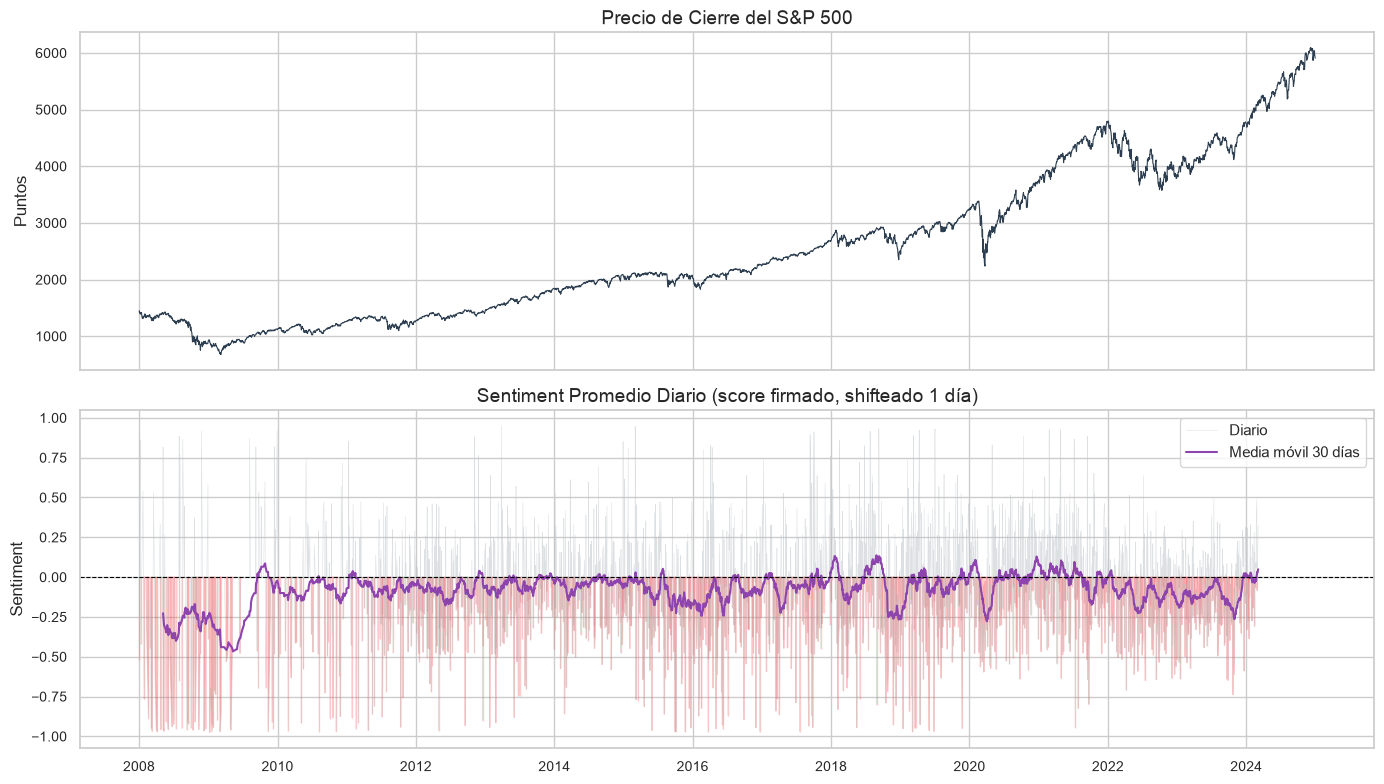


Correlación entre sentiment (shifteado) y retorno del día siguiente: 0.0031


In [6]:
sp500 = data_loader.load_sp500(RAW_DIR)

# Media móvil de 30 días del sentiment
sent_rolling = sentiment_diario["sentiment_mean"].rolling(30).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(sp500.index, sp500["Close"], color="#2c3e50", linewidth=0.8)
axes[0].set_title("Precio de Cierre del S&P 500")
axes[0].set_ylabel("Puntos")

axes[1].plot(sentiment_diario.index, sentiment_diario["sentiment_mean"],
             color="#bdc3c7", linewidth=0.4, alpha=0.5, label="Diario")
axes[1].plot(sent_rolling.index, sent_rolling.values,
             color="#8e44ad", linewidth=1.5, label="Media móvil 30 días")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].fill_between(sentiment_diario.index, sentiment_diario["sentiment_mean"], 0,
                     where=(sentiment_diario["sentiment_mean"] < 0),
                     alpha=0.2, color="red")
axes[1].set_title("Sentiment Promedio Diario (score firmado, shifteado 1 día)")
axes[1].set_ylabel("Sentiment")
axes[1].legend()

plt.tight_layout()
plt.show()

# Correlación sentiment → retorno siguiente día
merged = sp500[["Close"]].join(sentiment_diario[["sentiment_mean"]], how="inner")
merged["return_next"] = merged["Close"].pct_change().shift(-1)
corr = merged[["sentiment_mean", "return_next"]].corr().iloc[0, 1]
print(f"\nCorrelación entre sentiment (shifteado) y retorno del día siguiente: {corr:.4f}")

## Guardado del sentiment cache

El `sentiment_cache.csv` ya fue guardado por `load_or_run_finbert()` con los scores crudos. La versión agregada y shifteada (`sentiment_diario`) se construye en tiempo real cuando se necesita.

En el notebook 05 se usa `sentiment_diario` para construir la `feature_matrix.csv` final que incluye todas las features juntas.

In [7]:
print(f"Cache de sentiment en: {CACHE_PATH}")
print(f"Filas: {len(raw_sentiment):,} (una por noticia)")
print(f"\nSentiment diario (shifteado) listo para merge en notebook 05:")
print(f"  Shape: {sentiment_diario.shape}")
print(f"  Columnas: {list(sentiment_diario.columns)}")
print(f"  Período: {sentiment_diario.index[0].date()} → {sentiment_diario.index[-1].date()}")

Cache de sentiment en: ../data/processed/sentiment_cache.csv
Filas: 19,127 (una por noticia)

Sentiment diario (shifteado) listo para merge en notebook 05:
  Shape: (3507, 3)
  Columnas: ['sentiment_mean', 'sentiment_std', 'news_count']
  Período: 2008-01-02 → 2024-03-04
